In [1]:
import pandas as pd
import numpy as np
from pyecharts.charts import Page, Pie, WordCloud
from pyecharts import options as opts
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import time

# 设置 matplotlib 的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像时符号'-'显示为方块的问题

In [2]:
data=pd.read_csv('../data/job.csv')
data.head()

,职位名称,薪资范围,地点,工作经验,学历要求,岗位标签,公司名称,公司类型,公司规模,city
0,销售数据分析,1.2万-1.8万,上海,3-5年,本科,"['IT/互联网', 'Java', 'Python', 'SPSS', 'SAS', 'S...",云竞(上海)电子科技有限公司,民营,500-999人,上海
1,金融数据分析师,1.6万-1.8万,上海-黄浦,3-5年,本科,"['银行数据分析', '投融资数据分析', 'SQL', 'Python', '决策树']",北京戌华防务技术有限公司,民营,100-299人,上海
2,酒店财务数据分析,1.2万-1.5万,上海,3-5年,本科,['Power BI'],上海锦江国际酒店股份有限公司第一分公司,国企,100-299人,上海
3,数据分析经理,1.5万-1.8万,上海-徐汇,5-10年,本科,"['SQL', 'R', '数学/统计学专业', '线下零售', '餐饮业']",达美乐比萨,外商独资,500-999人,上海
4,IT校招-数据分析师(J13446),1万-2万,上海-青浦,不限,本科,"['Python', 'Tableau', '运营数据分析']",中通快递,股份制企业,10000人以上,上海


In [3]:
data.shape

(6685, 10)

In [4]:
#检查缺失值
missing_values = data.isnull().sum()
data = data.dropna(axis=0)
#检查重复值
duplicate_rows = data.duplicated().sum()
data = data.drop_duplicates()
data.shape

(6611, 10)

In [5]:
def convert_salary_range(salary_str):
    pattern = re.compile(r'([\d.]+)([千万])?-([\d.]+)([千万])?')
    match = pattern.match(salary_str)

    # 如果匹配失败，返回 NaN 值
    if match is None:
        return pd.Series([np.nan, np.nan], index=['最低薪资', '最高薪资'])

    # 提取匹配的组
    lower, lower_unit, upper, upper_unit = match.groups()

    # 转换为数值（单位：元）
    # 有"千"乘1000，有"万"乘10000，无单位则已经是元
    lower_val = float(lower)
    upper_val = float(upper)
    if lower_unit == '千':
        lower = lower_val * 1000
    elif lower_unit == '万':
        lower = lower_val * 10000
    else:
        lower = lower_val  # 已经是元，不要乘

    if upper_unit == '千':
        upper = upper_val * 1000
    elif upper_unit == '万':
        upper = upper_val * 10000
    else:
        upper = upper_val  # 已经是元，不要乘

    return pd.Series([lower, upper], index=['最低薪资', '最高薪资'])

data_salary_bounds = data["薪资范围"].apply(convert_salary_range)
data = pd.concat([data, data_salary_bounds], axis=1)

In [6]:
data.head()

,职位名称,薪资范围,地点,工作经验,学历要求,岗位标签,公司名称,公司类型,公司规模,city,最低薪资,最高薪资
0,销售数据分析,1.2万-1.8万,上海,3-5年,本科,"['IT/互联网', 'Java', 'Python', 'SPSS', 'SAS', 'S...",云竞(上海)电子科技有限公司,民营,500-999人,上海,12000.0,18000.0
1,金融数据分析师,1.6万-1.8万,上海-黄浦,3-5年,本科,"['银行数据分析', '投融资数据分析', 'SQL', 'Python', '决策树']",北京戌华防务技术有限公司,民营,100-299人,上海,16000.0,18000.0
2,酒店财务数据分析,1.2万-1.5万,上海,3-5年,本科,['Power BI'],上海锦江国际酒店股份有限公司第一分公司,国企,100-299人,上海,12000.0,15000.0
3,数据分析经理,1.5万-1.8万,上海-徐汇,5-10年,本科,"['SQL', 'R', '数学/统计学专业', '线下零售', '餐饮业']",达美乐比萨,外商独资,500-999人,上海,15000.0,18000.0
4,IT校招-数据分析师(J13446),1万-2万,上海-青浦,不限,本科,"['Python', 'Tableau', '运营数据分析']",中通快递,股份制企业,10000人以上,上海,10000.0,20000.0


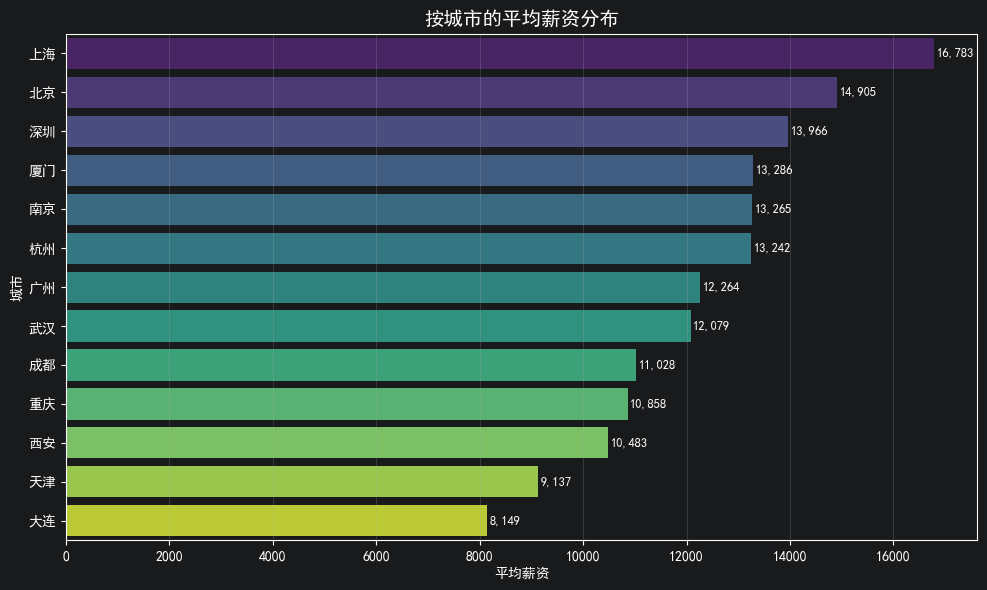

In [7]:
# 计算平均薪资列
data['平均薪资'] = (data['最低薪资'] + data['最高薪资']) / 2

# 计算每个城市的平均薪资
average_salary_by_city = data.groupby('city')['平均薪资'].mean().sort_values(ascending=False)

import os

# 创建 output 目录
os.makedirs('../output', exist_ok=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=average_salary_by_city.values, y=average_salary_by_city.index,
                 hue=average_salary_by_city.index, palette="viridis", legend=False)
# 添加数值标签
for i, v in enumerate(average_salary_by_city.values):
    ax.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)
plt.xlabel('平均薪资')
plt.ylabel('城市')
plt.title('按城市的平均薪资分布', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/按城市平均薪资分布.png', dpi=150)
plt.close()

In [8]:
# 生成词云图 - 基于岗位标签
all_tags = data['岗位标签'].str.split(',').explode().str.strip().str.replace(r'[\[\]]', '', regex=True).value_counts()
all_tags = all_tags[all_tags.index != '']

wc = WordCloud()
wc.add("", list(all_tags.items()), word_size_range=[20, 100])
wc.set_global_opts(title_opts=opts.TitleOpts(title="岗位标签词云图"))

# 直接在 notebook 中渲染
wc.render_notebook()

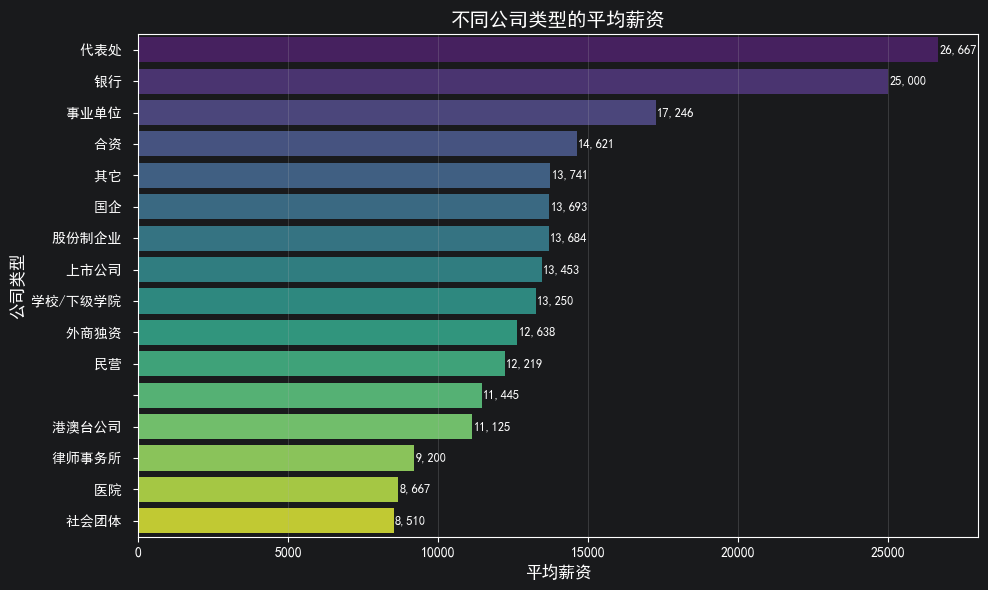

In [9]:
average_salary_by_industry = data.groupby('公司类型')['平均薪资'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=average_salary_by_industry.values, y=average_salary_by_industry.index,
                 hue=average_salary_by_industry.index, palette="viridis", legend=False)
for i, v in enumerate(average_salary_by_industry.values):
    ax.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)
plt.xlabel('平均薪资', fontsize=12)
plt.ylabel('公司类型', fontsize=12)
plt.title('不同公司类型的平均薪资', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/不同公司类型平均薪资.png', dpi=150)
plt.close()

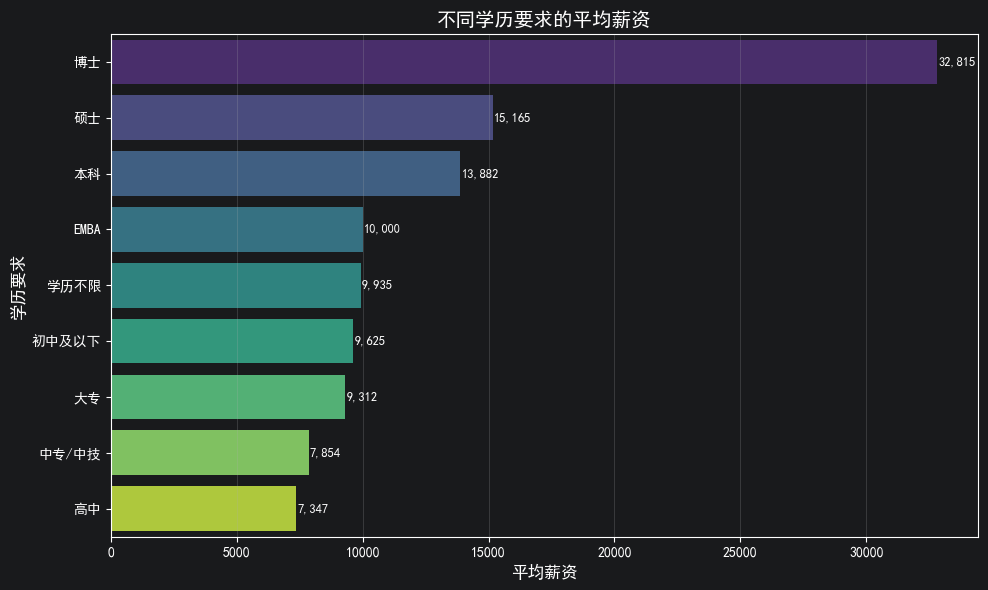

In [10]:
average_salary_by_education = data.groupby('学历要求')['平均薪资'].mean().sort_values(ascending=False)

# 注意：必须按排序后的顺序指定 y 轴类别顺序，否则 seaborn 会按字母排序
education_order = average_salary_by_education.index.tolist()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=average_salary_by_education.values, y=average_salary_by_education.index,
                 hue=average_salary_by_education.index, order=education_order, palette="viridis", legend=False)
for i, v in enumerate(average_salary_by_education.values):
    ax.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)
plt.xlabel('平均薪资', fontsize=12)
plt.ylabel('学历要求', fontsize=12)
plt.title('不同学历要求的平均薪资', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/学历与薪资关系分析.png', dpi=150)
plt.close()

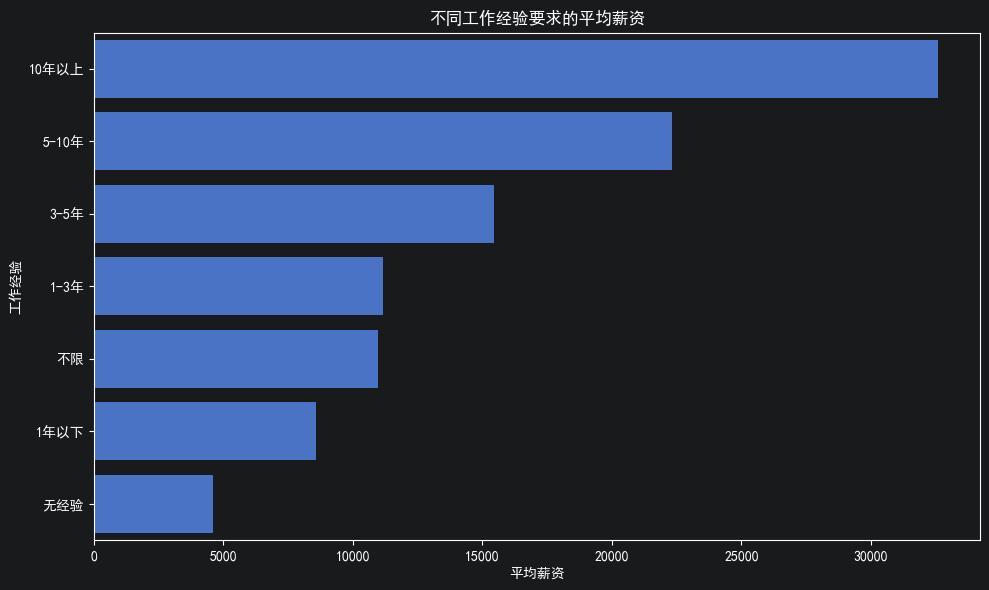

In [11]:
average_salary_by_experience = data.groupby('工作经验')['平均薪资'].mean().sort_values(ascending=False)
# 使用 seaborn 创建条形图
plt.figure(figsize=(10, 6))  # 设置图表大小
sns.barplot(x=average_salary_by_experience.values, y=average_salary_by_experience.index)
plt.xlabel('平均薪资')
plt.title('不同工作经验要求的平均薪资')
plt.tight_layout()
plt.show()
plt.savefig('../output/不同工作经验要求平均薪资.png', dpi=150)
plt.close()

7722.629262294628


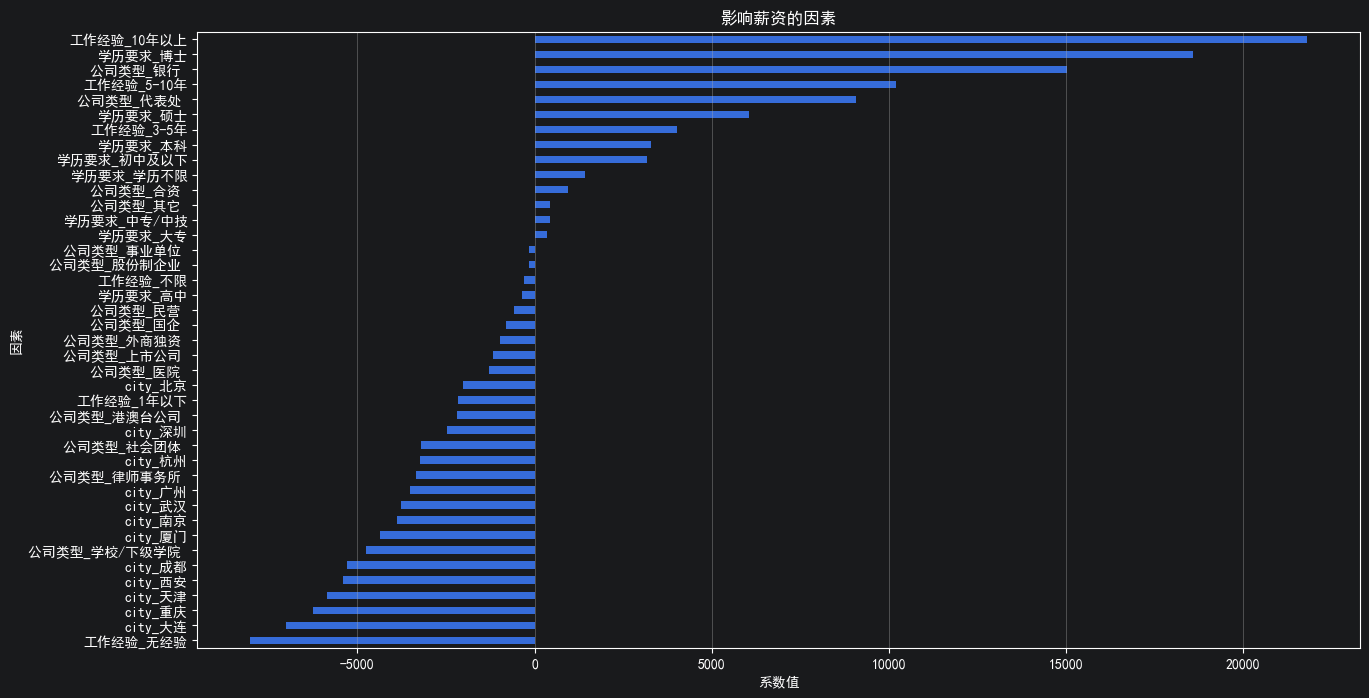

In [12]:
# 选择用于模型的变量
variables = ['工作经验', '学历要求', '公司类型', 'city']
target = '平均薪资'

data_model = data.copy()
data_model = data_model[variables + [target]].dropna()
data_model = data_model.replace([np.inf, -np.inf], np.nan).dropna()

# 对分类变量进行one-hot编码
data_encoded = pd.get_dummies(data_model[variables], drop_first=True)

# 将数据分割为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    data_encoded, data_model[target], test_size=0.2, random_state=42
)

# 初始化并拟合模型
model = LinearRegression()
model.fit(X_train, y_train)

# 进行预测并评估模型
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(rmse)

# 获取系数和截距
coefficients = pd.Series(model.coef_, index=data_encoded.columns)
intercept = model.intercept_

# 可视化系数
plt.figure(figsize=(15, 8))
coefficients.sort_values().plot(kind='barh')
plt.title('影响薪资的因素')
plt.xlabel('系数值')
plt.ylabel('因素')
plt.grid(axis='x')
plt.show()

In [13]:
# 填充 NaN + 对全量类别特征做独热编码
data['最低薪资'] = data['最低薪资'].fillna(data['最低薪资'].median())
data['最高薪资'] = data['最高薪资'].fillna(data['最高薪资'].median())
data['平均薪资'] = (data['最低薪资'] + data['最高薪资']) / 2
data['平均薪资'] = data['平均薪资'].fillna(data['平均薪资'].mean())

categorical_cols = ['city', '工作经验', '学历要求', '公司类型', '公司规模', '职位名称', '公司名称']
data_encoded = pd.get_dummies(data, columns=categorical_cols)
features_to_exclude = ['平均薪资', '薪资范围', '岗位标签', '最低薪资', '最高薪资', '地点'] + categorical_cols
X = data_encoded.drop(columns=features_to_exclude, errors='ignore')
X = X.fillna(X.mean())
y = data['平均薪资']

# 保存特征列名（用于后续预测时对齐）
feature_columns = X.columns.tolist()

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"X contains NaN: {X.isna().any().any()}")
print(f"y contains NaN: {y.isna().any()}")

X contains NaN: False
y contains NaN: False


In [20]:
# Ridge 超参调优
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_best = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_best.fit(X_train, y_train)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': ridge_best.best_estimator_,
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR (RBF Kernel)': SVR(kernel='rbf'),
}

results = []
trained_models = {}
scalers = {}

In [22]:
print("\n" + "=" * 70)
print("多模型训练与对比：")

for name, model in models.items():
    start = time.time()

    if name.startswith('SVR'):
        # SVR 对特征尺度敏感，需要标准化
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        scalers[name] = scaler
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        scalers[name] = None

    elapsed = time.time() - start
    trained_models[name] = model
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({'模型': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, '耗时(秒)': round(elapsed, 2)})
    print(f" >{name:30s}  RMSE={rmse:>10.2f}  MAE={mae:>10.2f}  R²={r2:.4f}  ({elapsed:.1f}s)")

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)


多模型训练与对比：
 >Linear Regression               RMSE=   5922.39  MAE=   4163.96  R²=0.4782  (50.1s)
 >Ridge Regression                RMSE=   5003.09  MAE=   3467.77  R²=0.6276  (2.5s)
 >Random Forest                   RMSE=   5371.30  MAE=   3413.18  R²=0.5708  (13.5s)
 >Gradient Boosting               RMSE=   5578.36  MAE=   4068.57  R²=0.5370  (30.7s)
 >SVR (RBF Kernel)                RMSE=   8311.02  MAE=   5269.00  R²=-0.0277  (144.8s)


In [23]:
print("\n" + "=" * 70)
print("各模型表现对比（按 RMSE 升序排列）")
print(results_df.to_string(index=False))

# 取 RMSE 最低的模型作为最佳模型
best_model_name = results_df.loc[0, '模型']
best_model = trained_models[best_model_name]
best_scaler = scalers[best_model_name]

print(f"\n{'=' * 70}")
print(f"最佳模型: {best_model_name}")
print(f"   RMSE: {results_df.loc[0, 'RMSE']:,.2f}")
print(f"   MAE:  {results_df.loc[0, 'MAE']:,.2f}")
print(f"   R²:   {results_df.loc[0, 'R²']:.4f}")


各模型表现对比（按 RMSE 升序排列）
               模型        RMSE         MAE        R²  耗时(秒)
 Ridge Regression 5003.086900 3467.774504  0.627588   2.51
    Random Forest 5371.299657 3413.176968  0.570754  13.55
Gradient Boosting 5578.358960 4068.573147  0.537022  30.73
Linear Regression 5922.393860 4163.963259  0.478154  50.08
 SVR (RBF Kernel) 8311.019423 5268.995499 -0.027676 144.82

最佳模型: Ridge Regression
   RMSE: 5,003.09
   MAE:  3,467.77
   R²:   0.6276


In [24]:
def predict_salary(education, experience, desired_city, desired_company_type,
                   desired_position, company_scale=None, company_name=None):
    user_data = pd.DataFrame([{
        '学历要求': education,
        '工作经验': experience,
        'city': desired_city,
        '公司类型': desired_company_type,
        '职位名称': desired_position,
        '公司规模': company_scale if company_scale else '',
        '公司名称': company_name if company_name else '',
    }])

    # 与训练时相同的独热编码
    user_encoded = pd.get_dummies(user_data, columns=categorical_cols)
    user_encoded = user_encoded.reindex(columns=feature_columns, fill_value=0)

    # 如果是 SVR 需要用相同的 scaler 做缩放
    if best_scaler is not None:
        user_encoded_scaled = best_scaler.transform(user_encoded)
        prediction = best_model.predict(user_encoded_scaled)[0]
    else:
        prediction = best_model.predict(user_encoded)[0]

    return round(prediction)

In [26]:
# 交互式薪资预测
print(f"\n{'=' * 50}")
print("薪资预测工具（基于最佳模型）")

education = input("请输入您的学历（例如：本科）: ")
experience = input("请输入您的工作经验（例如：1-3年）: ")
desired_city = input("请输入您希望工作的城市（例如：上海）: ")
desired_company_type = input("请输入您希望的公司类型（例如：国企）: ")
desired_position = input("请输入您希望的职位名称（例如：数据分析师）: ")

predicted_salary = predict_salary(
    education, experience, desired_city, desired_company_type, desired_position
)

print(f"{'=' * 50}")
print(f"基于您提供的信息，预计平均薪资为: {predicted_salary:,.0f} 元/月")
print(f"   （使用模型: {best_model_name}）")


薪资预测工具（基于最佳模型）

基于您提供的信息，预计平均薪资为: 12,822 元/月
   （使用模型: Ridge Regression）


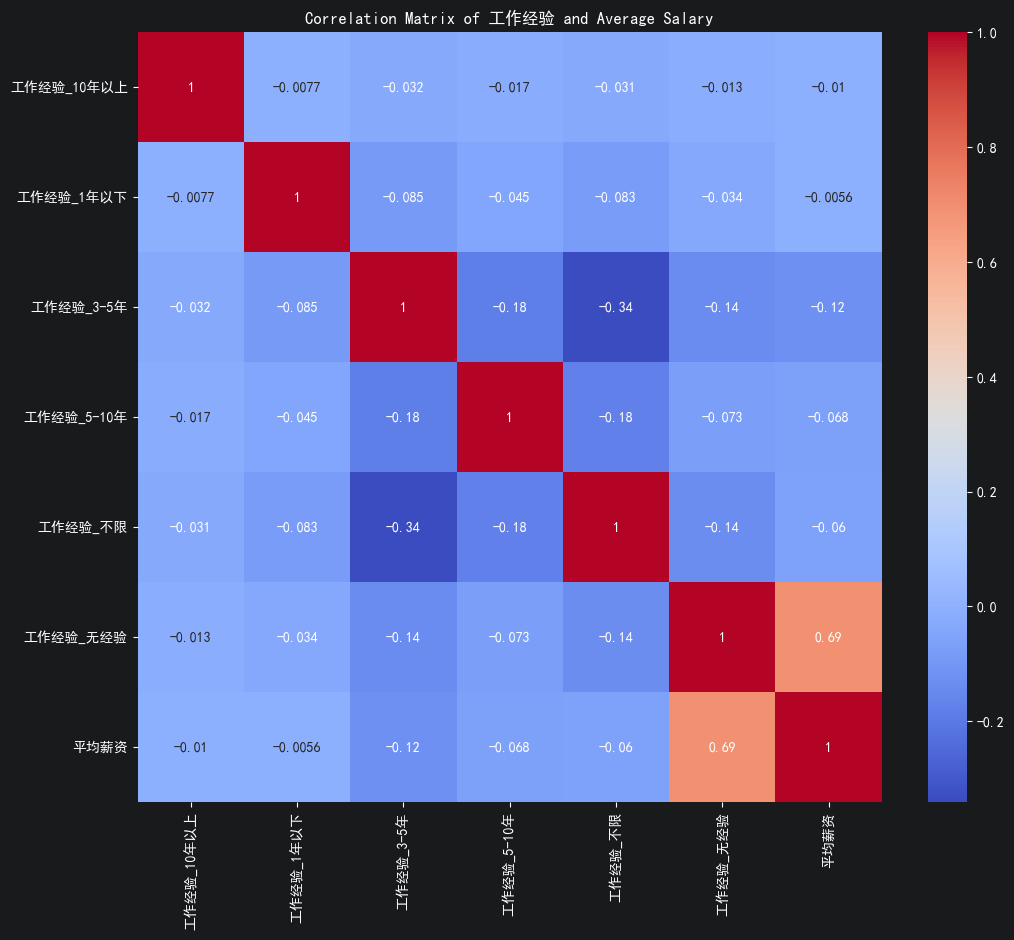

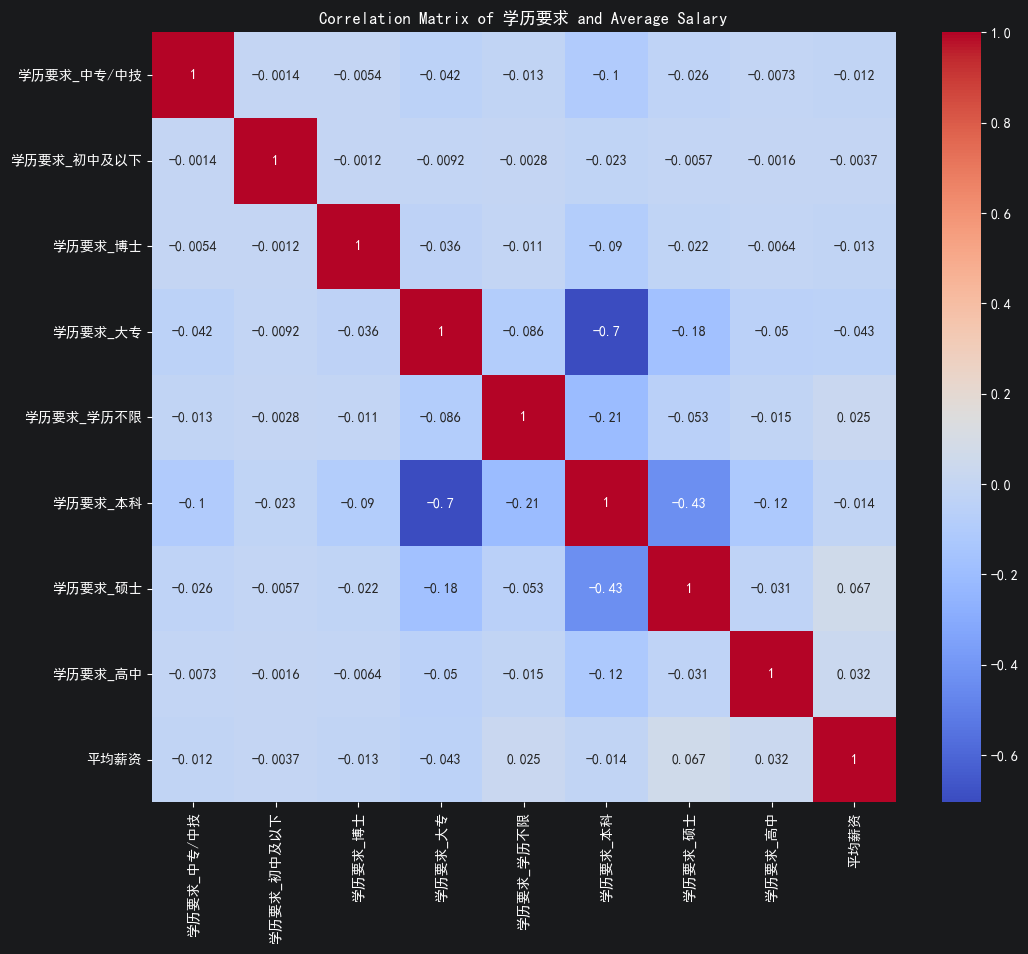

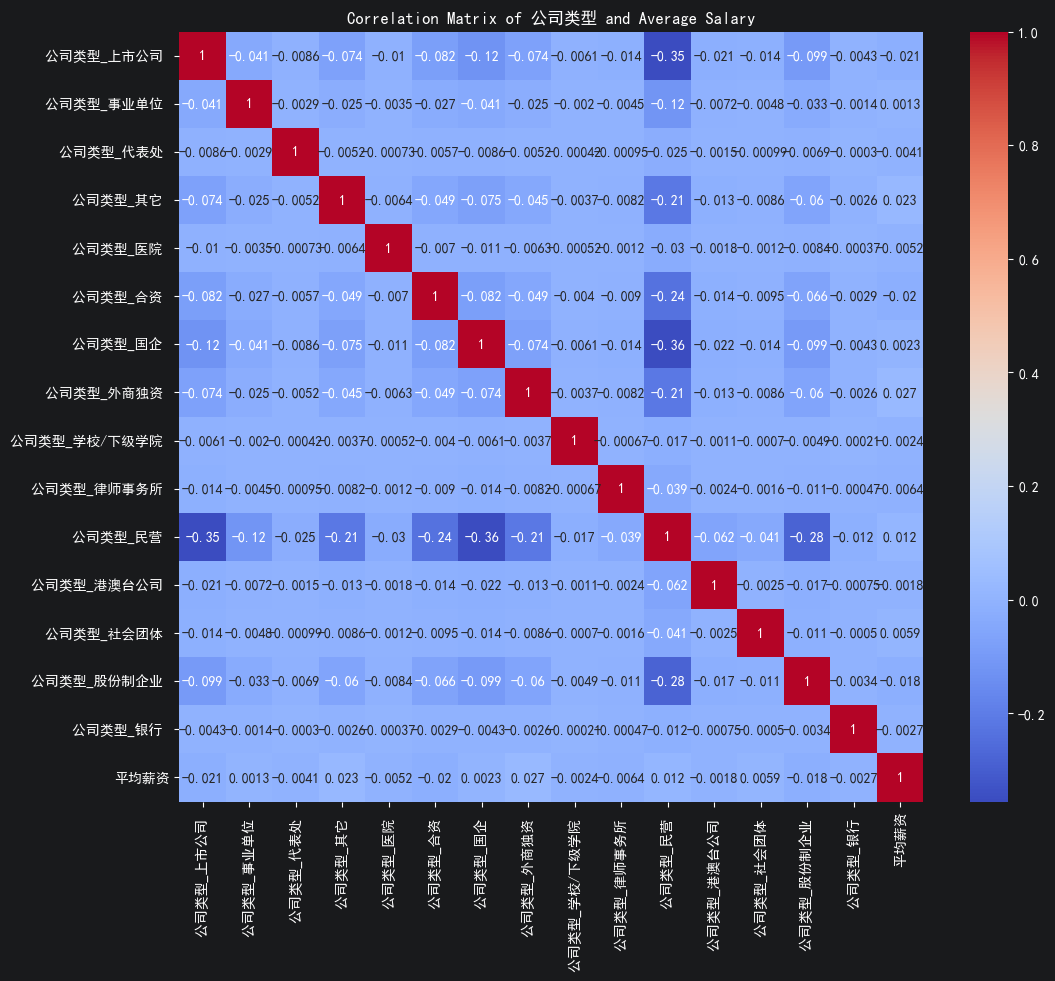

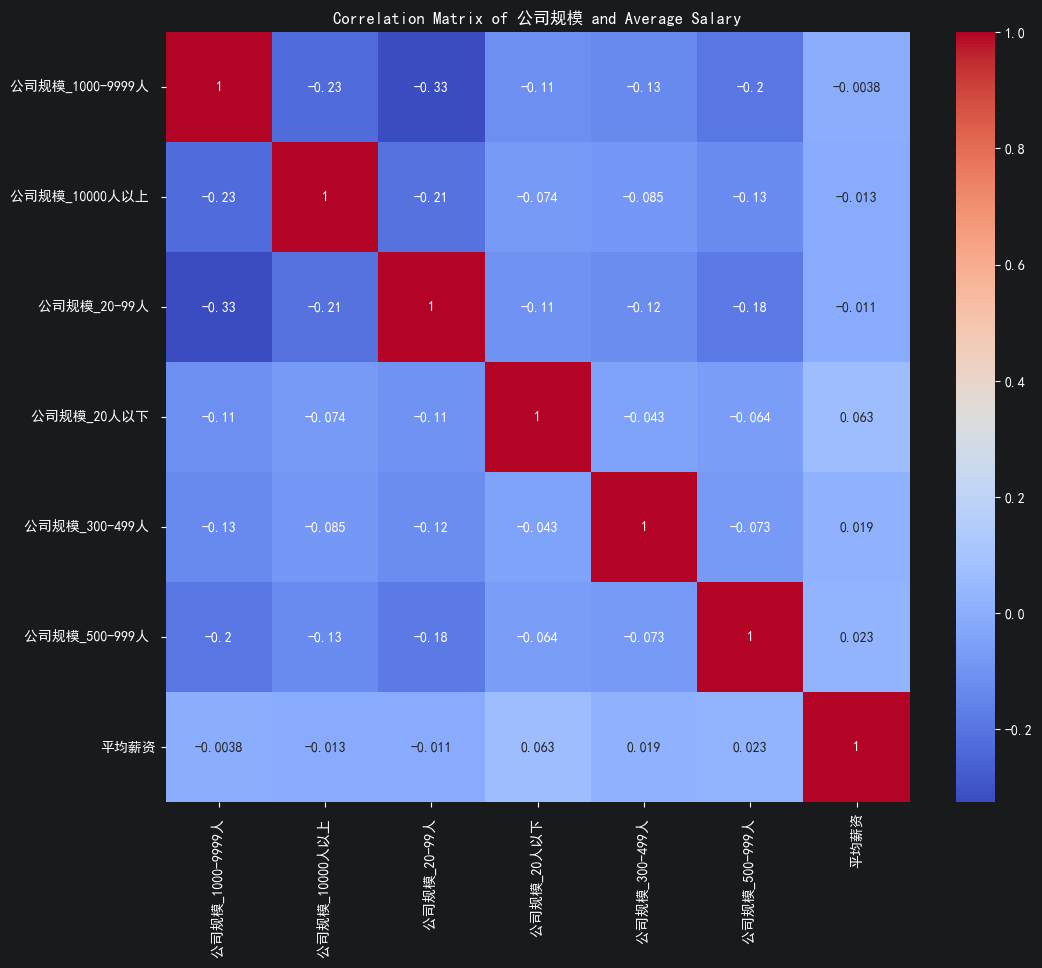

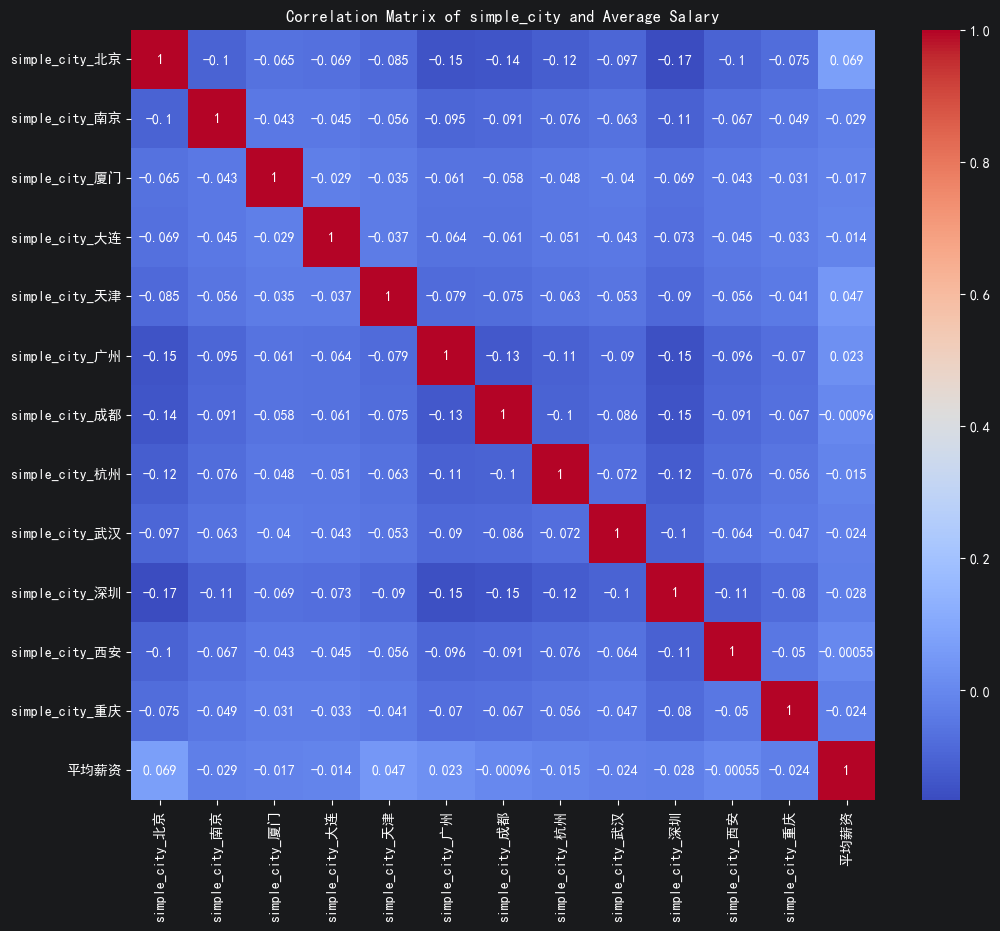

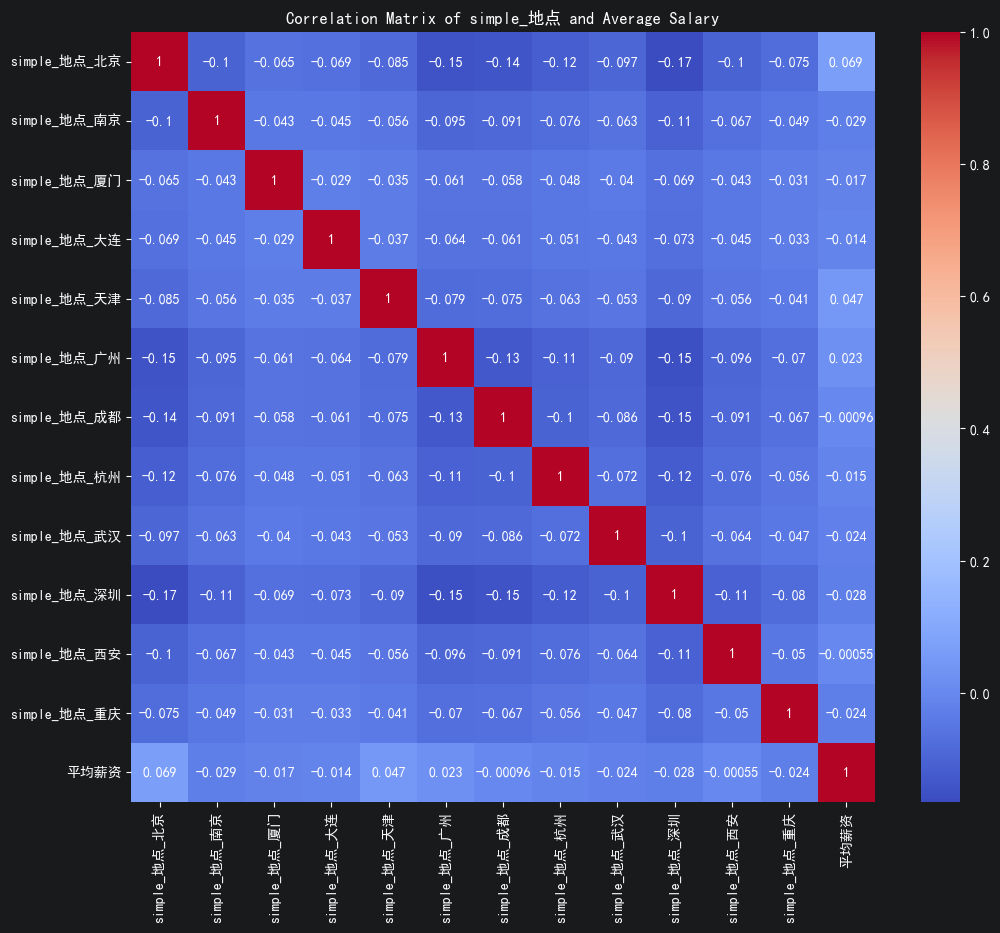

In [3]:
job_data = pd.read_csv('../data/job.csv')
job_data['simple_city'] = job_data['city'].apply(lambda x: x.split('-')[0])
job_data['simple_地点'] = job_data['地点'].apply(lambda x: x.split('-')[0])

# Extract and compute salaries
salary_split = job_data["薪资范围"].str.split("-", expand=True)
job_data["最低薪资"] = salary_split[0].str.extract("([\d.]+)").astype(float)
job_data["最高薪资"] = salary_split[1].str.extract("([\d.]+)").astype(float)
job_data["平均薪资"] = (job_data["最低薪资"] + job_data["最高薪资"]) / 2
# Define features and target
X = job_data.drop(columns=["平均薪资", "最低薪资", "最高薪资", "薪资范围", "职位名称", "岗位标签", "公司名称", "city", "地点"])
y = job_data["平均薪资"]

# Select categorical variables for one-hot encoding
categorical_features = ["工作经验", "学历要求", "公司类型", "公司规模", "simple_city", "simple_地点"]

# Perform one-hot encoding for the categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Add the target variable to the encoded features
X_encoded['平均薪资'] = y

# Loop through each categorical feature to visualize its correlation with the target
for feature in categorical_features:
    related_cols = [col for col in X_encoded.columns if feature in col]
    related_cols.append('平均薪资')

    # Compute the correlation matrix for columns related to the current feature
    corr_matrix = X_encoded[related_cols].corr()

    # Use seaborn to create a heatmap of the correlations
    plt.figure(figsize=(12,10))
    sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
    plt.title(f'Correlation Matrix of {feature} and Average Salary')
    plt.show()